Data Loading & Image Processing Pipeline

In [4]:
import numpy as np
import pandas as pd
import os
import glob
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Activation, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import backend as K

# PATHS 
BASE_PATH = '/kaggle/input/fall-2025-pu-prl-lab-performance-1'
SAMPLES_DIR = '/kaggle/input/competitions/fall-2025-pu-prl-lab-performance-1/mnist-bengali/samples'
TRAIN_CSV = '/kaggle/input/competitions/fall-2025-pu-prl-lab-performance-1/train.csv'

# Constants
RESIZE_DIM = 28 

# Monitoring Output
print(f"Samples directory exists: {os.path.exists(SAMPLES_DIR)}")
print(f"Train CSV exists: {os.path.exists(TRAIN_CSV)}")
sample_count = len(os.listdir(SAMPLES_DIR))
print(f"Total image files found: {sample_count}")

Samples directory exists: True
Train CSV exists: True
Total image files found: 61137


Visualizing the dataset after loading

--- First 10 Rows of Training CSV ---


,filename,digit
0,s_03259_a03259.png,3
1,s_12611_a12611.png,6
2,s_26403_c06342.png,6
3,s_50889_e06530.png,3
4,s_28513_c08452.png,7
5,s_25354_c05293.png,1
6,s_11121_a11121.png,0
7,s_50896_e06537.png,5
8,s_50142_e05783.png,3
9,s_31357_c11296.png,3



--- Visualizing First 10 Raw Images ---


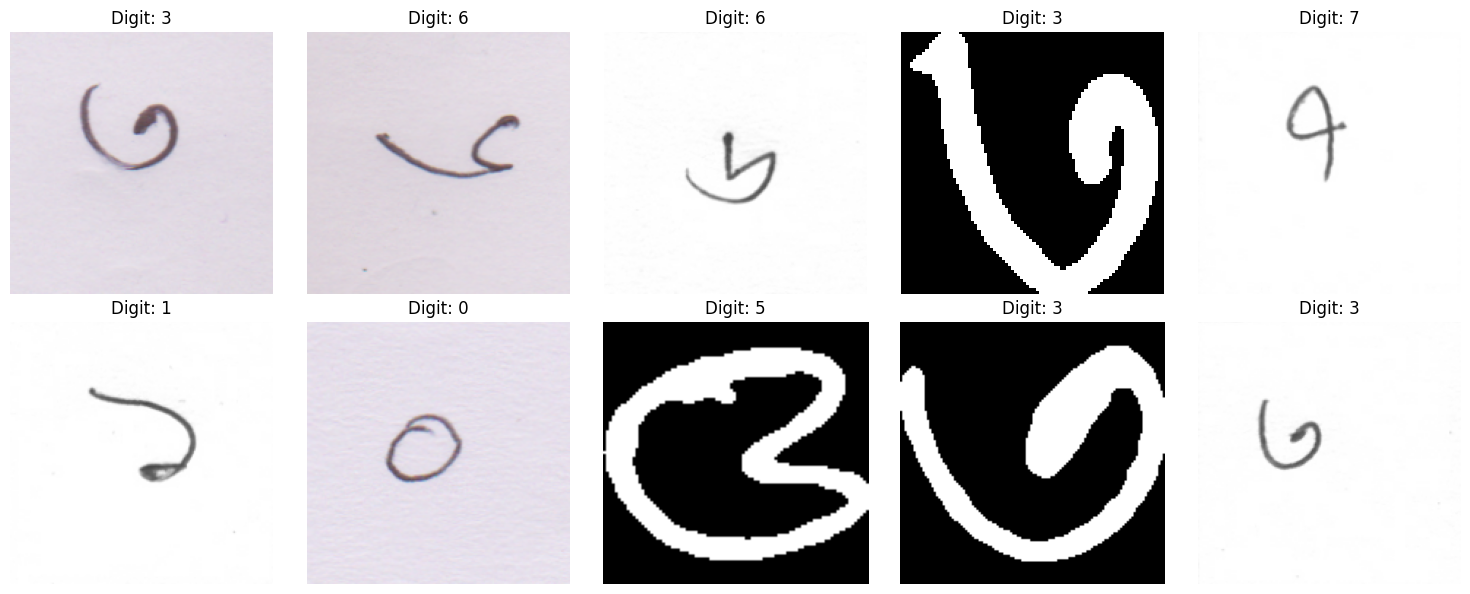

In [17]:
# Load the training labels
train_df = pd.read_csv(TRAIN_CSV)

# 1. Display the first 10 rows of the dataframe
print("--- First 10 Rows of Training CSV ---")
display(train_df.head(10))

# 2. Visualize the first 10 images from the directory
plt.figure(figsize=(15, 6))
print("\n--- Visualizing First 10 Raw Images ---")

for i in range(10):
    row = train_df.iloc[i]
    img_path = os.path.join(SAMPLES_DIR, row['filename'])
    
    # Load the image
    img = cv2.imread(img_path)
    
    if img is not None:
        # Convert BGR to RGB for correct colors in matplotlib
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(f"Digit: {row['digit']}")
        plt.axis('off')
    else:
        print(f"Warning: {row['filename']} not found.")

plt.tight_layout()
plt.show()

Image Enhancement

Visualizing first 10 enhanced images...


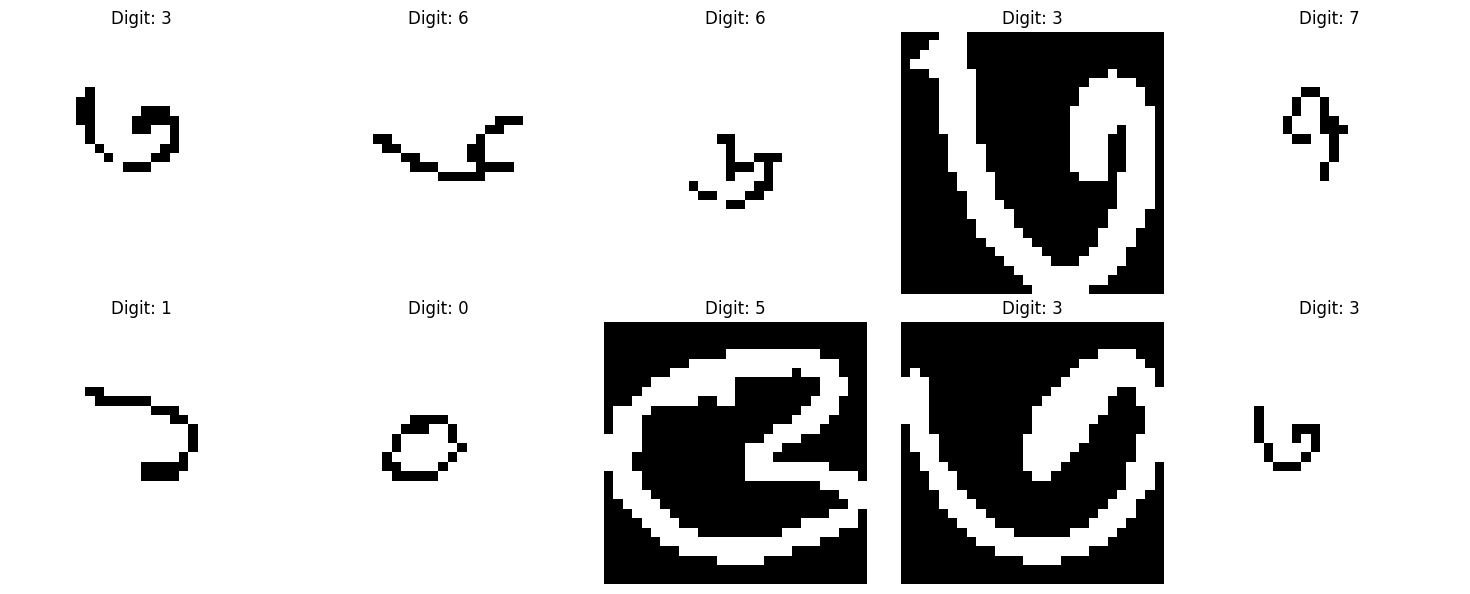

In [16]:
import matplotlib.pyplot as plt

# --- Visualization Cell: View First 10 Enhanced Images ---
plt.figure(figsize=(15, 6))
print("Visualizing first 10 enhanced images...")

for i in range(10):
    plt.subplot(2, 5, i + 1)
    
    # Reshape from (28, 28, 1) back to (28, 28) for display
    display_img = X_full[i].reshape(RESIZE_DIM, RESIZE_DIM)
    
    plt.imshow(display_img, cmap='gray')
    
    # If labels exist, show them as the title
    if y_full is not None:
        label = np.argmax(y_full[i])
        plt.title(f"Digit: {label}")
    
    plt.axis('off')

plt.tight_layout()
plt.show()

visualization

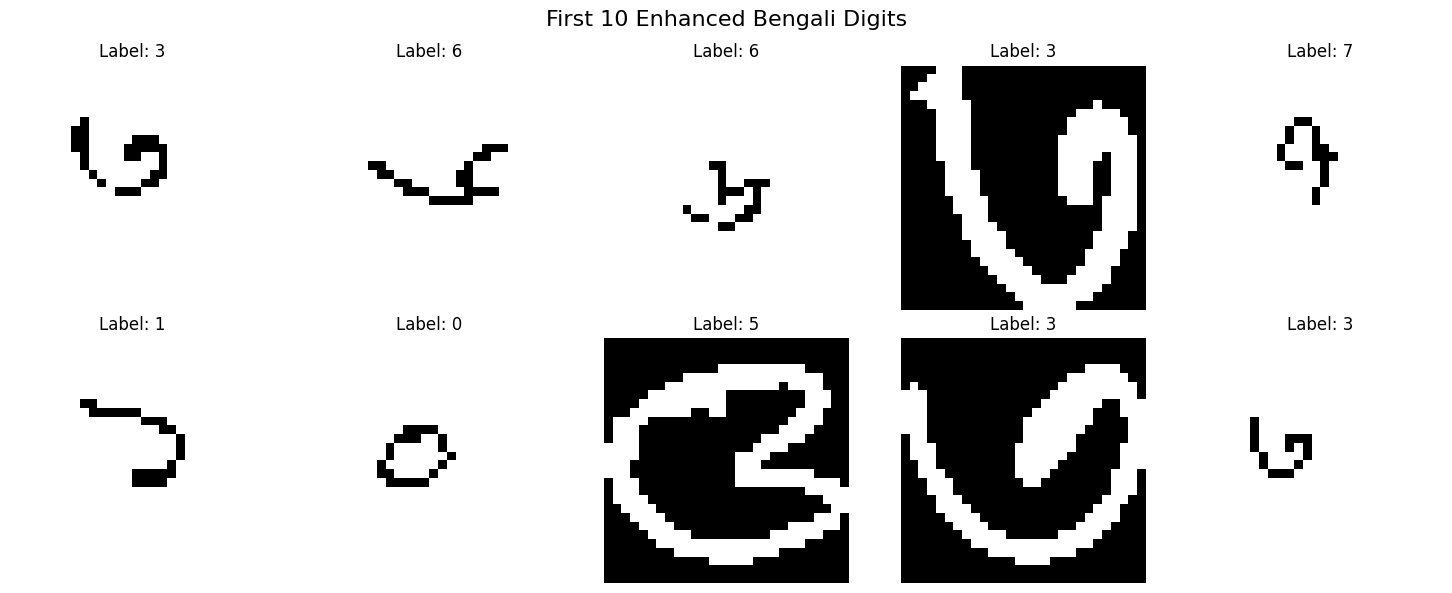

In [14]:
import matplotlib.pyplot as plt

# Visualization of the first 10 processed images
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    
    # Reshape back to 2D for plotting (removing the single channel dimension)
    img_display = X_full[i].reshape(RESIZE_DIM, RESIZE_DIM)
    
    plt.imshow(img_display, cmap='gray')
    
    # Show label if it exists
    if y_full is not None:
        label = np.argmax(y_full[i])
        plt.title(f"Label: {label}")
    
    plt.axis('off')

plt.suptitle("First 10 Enhanced Bengali Digits", fontsize=16)
plt.tight_layout()
plt.show()

Train-Test Split & Data Augmentation

In [6]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Stratified Split (85% Train, 15% Val)
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.15, random_state=42, stratify=np.argmax(y_full, axis=1)
)

# 2. Augmentation 
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    fill_mode='nearest'
)

print(f"Split Complete. Training on {len(X_train)} samples, Validating on {len(X_val)} samples.")

Split Complete. Training on 31179 samples, Validating on 5503 samples.


Custom CNN & Training

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam

def build_custom_cnn(input_shape=(RESIZE_DIM, RESIZE_DIM, 1)):
    model = Sequential([
        Input(shape=input_shape),
        
        # Block 1: Basic features (edges/curves)
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Block 2: Complex shapes
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Block 3: High-level patterns
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.4),
        
        # Fully Connected Head
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_custom_cnn()

# --- Callbacks ---
callbacks = [
    # Using .keras extension as per modern standards
    ModelCheckpoint('best_cnn_bengali.keras', save_best_only=True, monitor='val_accuracy', mode='max'),
    
    # Early Stopping: Ends training if no improvement in 8 epochs
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    
    # Reduce LR: Halves the learning rate if the model plateaus
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
]

print("🚀 Starting Custom CNN Training...")
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64), # Increased batch size for CNN stability
    validation_data=(X_val, y_val),
    epochs=50, # Custom CNNs can take more epochs than pre-trained ones
    callbacks=callbacks,
    verbose=1
)

I0000 00:00:1774960176.618101      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


🚀 Starting Custom CNN Training...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1774960182.157801     136 service.cc:152] XLA service 0x7d31b801cfc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774960182.157847     136 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774960183.055410     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


 10/488 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.0832 - loss: 3.7071  

I0000 00:00:1774960189.791480     136 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


488/488 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.3541 - loss: 2.1485 - val_accuracy: 0.8310 - val_loss: 0.5279 - learning_rate: 0.0010
Epoch 2/50
488/488 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.7854 - loss: 0.6135 - val_accuracy: 0.8508 - val_loss: 0.4247 - learning_rate: 0.0010
Epoch 3/50
488/488 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8586 - loss: 0.4255 - val_accuracy: 0.9315 - val_loss: 0.2003 - learning_rate: 0.0010
Epoch 4/50
488/488 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8946 - loss: 0.3151 - val_accuracy: 0.9337 - val_loss: 0.2210 - learning_rate: 0.0010
Epoch 5/50
488/488 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9098 - loss: 0.2804 - val_accuracy: 0.9497 - val_loss: 0.1594 - learning_rate: 0.0010
Epoch 6/50
488/488 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9158 - loss: 0.2561 - val_accuracy: 0.9593 - val_loss: 0.1344 - learning_rate: 0.0010
Epoch 7/50
488/488 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9275 - loss: 0.2323

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,368 (5.01 MB)

 Trainable params: 437,738 (1.67 MB)

 Non-trainable params: 1,152 (4.50 KB)

 Optimizer params: 875,478 (3.34 MB)

Model Evaluation & Metrics

Generating predictions for validation set...
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Digit 0       0.99      0.98      0.99       552
     Digit 1       0.98      0.96      0.97       548
     Digit 2       0.99      1.00      0.99       551
     Digit 3       0.99      0.99      0.99       551
     Digit 4       0.98      0.99      0.99       553
     Digit 5       0.98      0.98      0.98       552
     Digit 6       1.00      0.98      0.99       553
     Digit 7       0.99      0.99      0.99       550
     Digit 8       1.00      0.99      0.99       546
     Digit 9       0.97      0.98      0.98       547

    accuracy                           0.99      5503
   macro avg       0.99      0.99      0.99      5503
weighted avg       0.99      0.99      0.99      5503



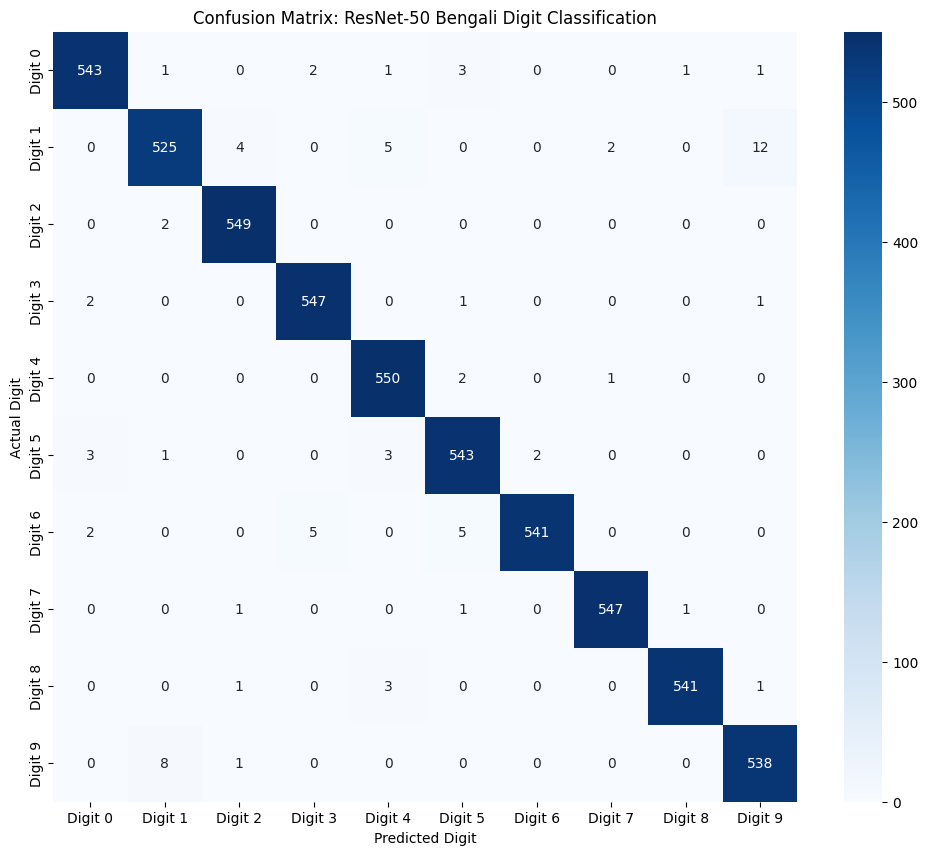

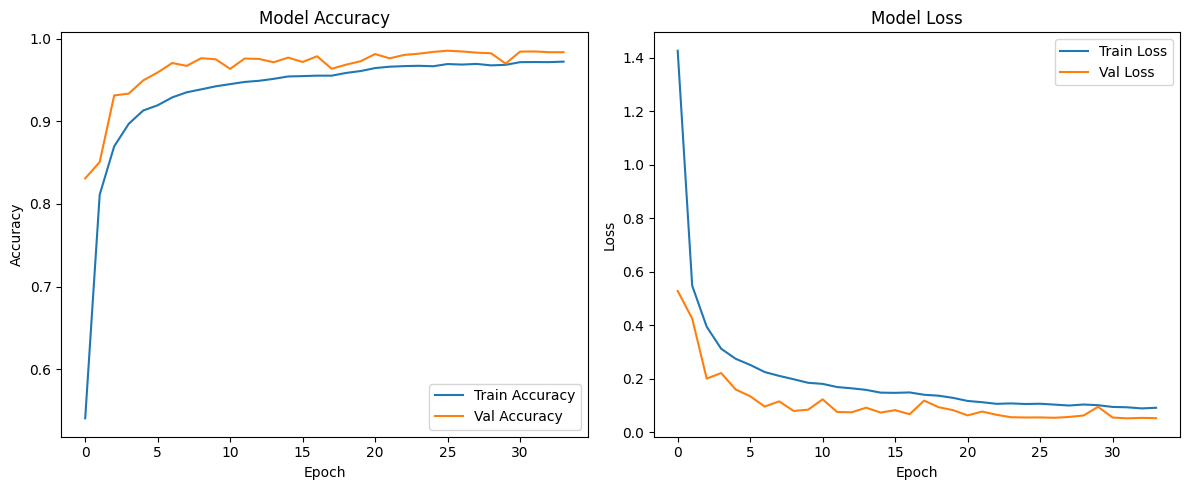

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate Predictions on Validation Set
print("Generating predictions for validation set...")
y_pred_probs = model.predict(X_val, batch_size=64, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)

# 2. Detailed Classification 
print("\n--- Detailed Classification Report ---")
# Mapping 0-9 for Bengali digits
target_names = [f'Digit {i}' for i in range(10)]
print(classification_report(y_true, y_pred, target_names=target_names))

# 3. Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: ResNet-50 Bengali Digit Classification')
plt.ylabel('Actual Digit')
plt.xlabel('Predicted Digit')
plt.show()

# 4. Accuracy/Loss Curves from Training History
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Prediction & Final Submission File

In [12]:
import numpy as np
import os
import pandas as pd
import cv2

# --- REDEFINE PATHS AND CONSTANTS ---
# This ensures the cell works even if the environment was reset
SAMPLES_DIR = '/kaggle/input/competitions/fall-2025-pu-prl-lab-performance-1/mnist-bengali/samples'
RESIZE_DIM = 28 

# 1. Load weights for the Custom CNN
model_path = 'best_cnn_bengali.keras'

if os.path.exists(model_path):
    model.load_weights(model_path)
    print(f"✅ Successfully loaded weights from {model_path}")
else:
    print(f"❌ Error: {model_path} not found. Ensure you ran the training cell successfully.")

# 2. Load Sample Submission template
SUB_TEMPLATE = '/kaggle/input/competitions/fall-2025-pu-prl-lab-performance-1/sample_submission.csv'
sub_df = pd.read_csv(SUB_TEMPLATE)

X_test = []
print("🔍 Processing test set images...")

for i, row in sub_df.iterrows():
    img_path = os.path.join(SAMPLES_DIR, row['filename'])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        # Handle cases where image might be missing
        X_test.append(np.zeros((RESIZE_DIM, RESIZE_DIM, 1)))
        continue
    
    # --- EXACT SAME enhancement pipeline as used in training ---
    img = cv2.resize(img, (RESIZE_DIM, RESIZE_DIM), interpolation=cv2.INTER_AREA)
    
    # Sharpening (Gaussian unblur)
    gauss = cv2.GaussianBlur(img, (9,9), 10.0)
    img = cv2.addWeighted(img, 1.5, gauss, -0.5, 0)
    
    # Binary Thresholding (Otsu)
    _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Reshape for single channel Custom CNN input
    img = img.reshape(RESIZE_DIM, RESIZE_DIM, 1)
    
    X_test.append(img)
    if i % 5000 == 0: 
        print(f"Processed {i} test images...", end="\r")

# Convert list to numpy array and normalize
X_test = np.array(X_test).astype('float32') / 255.0

# 3. Run Inference
print("\n🧠 Generating predictions...")
preds = model.predict(X_test, batch_size=64, verbose=1)
sub_df['digit'] = np.argmax(preds, axis=1)

# 4. Final Export
sub_df.to_csv('submission.csv', index=False)
print("submission.csv is ready for upload!")

✅ Successfully loaded weights from best_cnn_bengali.keras
🔍 Processing test set images...
Processed 20000 test images...
🧠 Generating predictions...
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
submission.csv is ready for upload!
